In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [19]:
# Force-download the specific dataset directly into your notebook session
import os
!pip install -q kagglehub
import kagglehub

# This pulls the exact dataset link you found earlier
downloaded_path = kagglehub.dataset_download("engeddy/astrophysical-objects-image-dataset")
print("Dataset successfully downloaded to:", downloaded_path)

Dataset successfully downloaded to: /kaggle/input/datasets/engeddy/astrophysical-objects-image-dataset


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Use the exact path printed by your kagglehub tool
DATASET_PATH = '/kaggle/input/datasets/engeddy/astrophysical-objects-image-dataset'
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

print("--- Initializing Data Generators ---")

# 1. Training Augmentation Generator (80% Split)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# 2. Validation/Test Generator (Remaining 20%)
val_datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2
)

# Create streaming pipelines
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f"\nSuccessfully verified path! Loaded {num_classes} cosmic classes: {class_names}")

--- Initializing Data Generators ---
Found 2736 images belonging to 1 classes.
Found 683 images belonging to 1 classes.

Successfully verified path! Loaded 1 cosmic classes: ['astro_dataset_maxia']


In [21]:
# Check the exact folder names inside your downloaded dataset
import os
print(os.listdir('/kaggle/input/datasets/engeddy/astrophysical-objects-image-dataset'))

['readme.md', 'astro_dataset_maxia']


In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# FIXED PATH: Points exactly inside the active cosmic subfolder
DATASET_PATH = '/kaggle/input/datasets/engeddy/astrophysical-objects-image-dataset/astro_dataset_maxia'
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

print("--- Initializing Data Generators ---")

# 1. Training Augmentation Generator (80% Split)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# 2. Validation/Test Generator (Remaining 20%)
val_datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2
)

# Create streaming pipelines
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f"\nSuccessfully verified path! Loaded {num_classes} cosmic classes: {class_names}")

--- Initializing Data Generators ---
Found 2736 images belonging to 1 classes.
Found 683 images belonging to 1 classes.

Successfully verified path! Loaded 1 cosmic classes: ['astro_dataset_maxia']


In [24]:
import os
base = '/kaggle/input/datasets/engeddy/astrophysical-objects-image-dataset/astro_dataset_maxia'
print("Contents of astro_dataset_maxia:", os.listdir(base))

# Let's check if there is another nested folder inside it
nested_path = os.path.join(base, 'astro_dataset_maxia')
if os.path.exists(nested_path):
    print("Deep nested contents:", os.listdir(nested_path))

Contents of astro_dataset_maxia: ['astro_dataset_maxia']
Deep nested contents: ['validation', 'training', 'test']


In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# POINT DIRECTLY TO THE PRE-SPLIT NESTED FOLDERS
TRAIN_PATH = '/kaggle/input/datasets/engeddy/astrophysical-objects-image-dataset/astro_dataset_maxia/astro_dataset_maxia/training'
VAL_PATH = '/kaggle/input/datasets/engeddy/astrophysical-objects-image-dataset/astro_dataset_maxia/astro_dataset_maxia/validation'

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

print("--- Initializing Pre-Split Data Generators ---")

# Training Data Generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Validation Data Generator (Pure Rescaling only)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load directly from the respective pre-split directories
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f"\nSuccess! Found {num_classes} cosmic classes: {class_names}")

--- Initializing Pre-Split Data Generators ---
Found 2416 images belonging to 12 classes.
Found 658 images belonging to 12 classes.

Success! Found 12 cosmic classes: ['asteroid', 'black_hole', 'earth', 'galaxy', 'jupiter', 'mars', 'mercury', 'neptune', 'pluto', 'saturn', 'uranus', 'venus']


In [26]:
print("--- Building Custom Sequential CNN Framework ---")

custom_cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

custom_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Starting Custom CNN Training Loop ---")
history_custom = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

--- Building Custom Sequential CNN Framework ---


I0000 00:00:1780819575.292817      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780819575.298725      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



--- Starting Custom CNN Training Loop ---
Epoch 1/5


I0000 00:00:1780819581.673846     157 service.cc:152] XLA service 0x7c8aac005ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780819581.673895     157 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780819581.673901     157 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780819582.035993     157 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-07 08:06:23.662546: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 08:06:23.810251: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/76 ━━━━━━━━━━━━━━━━━━━━ 7:14 6s/step - accuracy: 0.0625 - loss: 2.4963

I0000 00:00:1780819585.381345     157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


73/76 ━━━━━━━━━━━━━━━━━━━━ 2s 741ms/step - accuracy: 0.3000 - loss: 1.9864

2026-06-07 08:07:19.815982: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 08:07:19.960265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


76/76 ━━━━━━━━━━━━━━━━━━━━ 75s 918ms/step - accuracy: 0.4611 - loss: 1.5280 - val_accuracy: 0.6884 - val_loss: 1.0279
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 39s 509ms/step - accuracy: 0.7127 - loss: 0.8343 - val_accuracy: 0.7614 - val_loss: 0.8392
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 39s 515ms/step - accuracy: 0.7690 - loss: 0.6759 - val_accuracy: 0.8131 - val_loss: 0.6113
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 39s 506ms/step - accuracy: 0.8320 - loss: 0.5386 - val_accuracy: 0.8541 - val_loss: 0.4785
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 38s 501ms/step - accuracy: 0.8485 - loss: 0.4485 - val_accuracy: 0.8313 - val_loss: 0.6026


In [27]:
print("--- Initializing Transfer Learning Framework ---")

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3), 
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False 

transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Starting Transfer Learning Training Loop ---")
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

--- Initializing Transfer Learning Framework ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Starting Transfer Learning Training Loop ---
Epoch 1/5


2026-06-07 08:13:02.252070: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 08:13:02.389109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


35/76 ━━━━━━━━━━━━━━━━━━━━ 17s 434ms/step - accuracy: 0.4738 - loss: 1.6458

2026-06-07 08:13:27.545654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 08:13:27.682194: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.6202 - loss: 1.1999

2026-06-07 08:14:07.240401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 08:14:07.377640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


76/76 ━━━━━━━━━━━━━━━━━━━━ 81s 864ms/step - accuracy: 0.7901 - loss: 0.6810 - val_accuracy: 0.9438 - val_loss: 0.2254
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 39s 508ms/step - accuracy: 0.9582 - loss: 0.1637 - val_accuracy: 0.9605 - val_loss: 0.1369
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 38s 508ms/step - accuracy: 0.9748 - loss: 0.0914 - val_accuracy: 0.9711 - val_loss: 0.1129
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 38s 504ms/step - accuracy: 0.9839 - loss: 0.0692 - val_accuracy: 0.9818 - val_loss: 0.0830
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 38s 508ms/step - accuracy: 0.9934 - loss: 0.0419 - val_accuracy: 0.9711 - val_loss: 0.0907


--- Generating Comparison Metrics & Archiving Figures ---


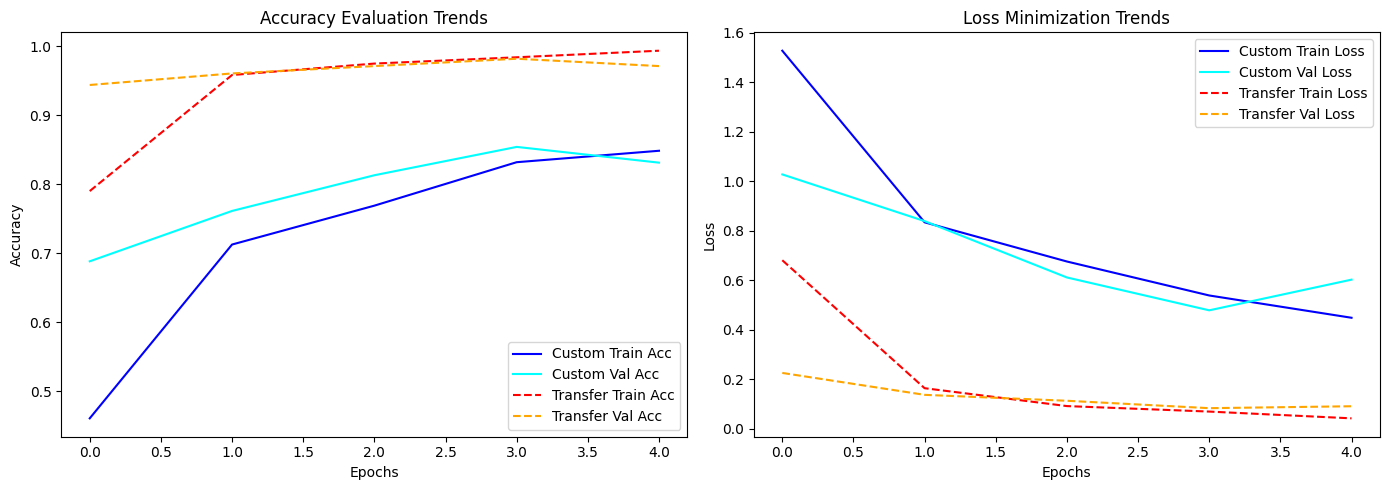

21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step


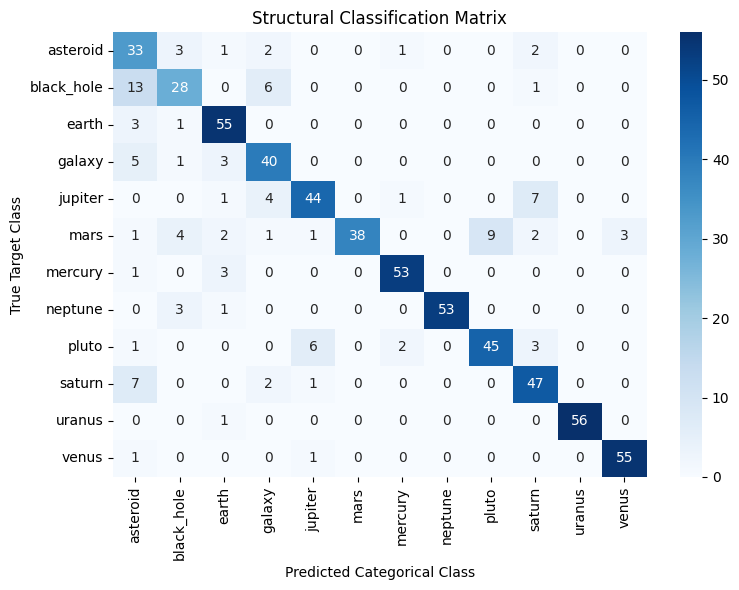


--- PHASE II DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    asteroid       0.51      0.79      0.62        42
  black_hole       0.70      0.58      0.64        48
       earth       0.82      0.93      0.87        59
      galaxy       0.73      0.82      0.77        49
     jupiter       0.83      0.77      0.80        57
        mars       1.00      0.62      0.77        61
     mercury       0.93      0.93      0.93        57
     neptune       1.00      0.93      0.96        57
       pluto       0.83      0.79      0.81        57
      saturn       0.76      0.82      0.79        57
      uranus       1.00      0.98      0.99        57
       venus       0.95      0.96      0.96        57

    accuracy                           0.83       658
   macro avg       0.84      0.83      0.83       658
weighted avg       0.85      0.83      0.83       658



In [28]:
print("--- Generating Comparison Metrics & Archiving Figures ---")

# 1. Performance Curve Plots
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_custom.history['accuracy'], label='Custom Train Acc', color='blue')
plt.plot(history_custom.history['val_accuracy'], label='Custom Val Acc', color='cyan')
plt.plot(history_transfer.history['accuracy'], label='Transfer Train Acc', color='red', linestyle='--')
plt.plot(history_transfer.history['val_accuracy'], label='Transfer Val Acc', color='orange', linestyle='--')
plt.title('Accuracy Evaluation Trends')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_custom.history['loss'], label='Custom Train Loss', color='blue')
plt.plot(history_custom.history['val_loss'], label='Custom Val Loss', color='cyan')
plt.plot(history_transfer.history['loss'], label='Transfer Train Loss', color='red', linestyle='--')
plt.plot(history_transfer.history['val_loss'], label='Transfer Val Loss', color='orange', linestyle='--')
plt.title('Loss Minimization Trends')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_loss_performance.png')
plt.show()

# 2. Confusion Matrix Map
val_generator.reset()
predictions = custom_cnn.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Structural Classification Matrix')
plt.xlabel('Predicted Categorical Class')
plt.ylabel('True Target Class')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# 3. Text Report Output
print("\n--- PHASE II DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))